In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_train.csv
/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_sample_submission.csv
/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_test.csv


**1. Loading and viewing Dataset**

In [2]:
train=pd.read_csv("/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_train.csv")
test=pd.read_csv("/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_test.csv")
submit=pd.read_csv("/kaggle/input/competitions/survivor-detection-challenge-classification/maritime_sample_submission.csv")

In [3]:
train.shape

(712, 16)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      712 non-null    float64
 1   TicketTier       712 non-null    float64
 2   PassengerName    712 non-null    object 
 3   Gender           712 non-null    object 
 4   Age              515 non-null    float64
 5   RelativesAboard  712 non-null    float64
 6   ParentsChildren  712 non-null    float64
 7   CLass            712 non-null    object 
 8   TicketCost       712 non-null    float64
 9   Berth            159 non-null    object 
 10  BoardingPort     710 non-null    object 
 11  FamilySize       712 non-null    int64  
 12  Singleton        712 non-null    int64  
 13  FarePerPerson    712 non-null    float64
 14  Title            712 non-null    object 
 15  Outcome          712 non-null    int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 89.1+ KB


In [5]:
train.head()

,PassengerId,TicketTier,PassengerName,Gender,Age,RelativesAboard,ParentsChildren,CLass,TicketCost,Berth,BoardingPort,FamilySize,Singleton,FarePerPerson,Title,Outcome
0,338.376107,0.977533,"Partner, Mr. Austen",male,NaN,0.005991,-0.024062,113043,29.104891,C124,S,1,1,25.906873,Mr,0
1,732.225160,2.016456,"Berriman, Mr. William John",male,21.574386,0.091114,-0.021340,28425,11.033567,NaN,S,1,1,10.939094,Mr,0
2,391.314100,2.998448,"Tikkanen, Mr. Juho",male,33.490756,-0.072885,-0.021702,STON/O 2. 3101293,2.234540,NaN,S,1,1,4.065968,Mr,0
3,724.550481,3.045488,"Hansen, Mr. Henrik Juul",male,25.200171,0.913680,0.032986,350025,10.958320,NaN,S,2,0,3.733784,Mr,0
4,810.994274,3.004710,"Andersson, Miss. Ebba Iris Alfrida",female,5.839590,4.009691,1.956266,347082,33.765343,NaN,S,7,0,3.325612,Miss,0


In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,712.0,448.089668,256.347351,-19.969283,222.160559,455.043258,671.639433,905.400989
TicketTier,712.0,2.333755,0.826466,0.893173,1.954529,2.954504,3.006993,3.108531
Age,515.0,29.783025,14.605177,-1.128370,20.666161,28.374231,38.707210,79.849115
RelativesAboard,712.0,0.555223,1.174990,-0.148789,-0.016907,0.040156,0.967004,8.027245
ParentsChildren,712.0,0.378523,0.791899,-0.115958,-0.020213,0.017184,0.082670,6.045675
TicketCost,712.0,32.456248,52.079443,-3.982686,8.380745,14.833240,30.775352,514.074158
FamilySize,712.0,1.932584,1.682525,1.000000,1.000000,1.000000,2.000000,11.000000
Singleton,712.0,0.602528,0.489719,0.000000,0.000000,1.000000,1.000000,1.000000
FarePerPerson,712.0,20.043894,38.109959,-4.526815,6.596378,9.272521,18.980591,512.004226
Outcome,712.0,0.376404,0.484824,0.000000,0.000000,0.000000,1.000000,1.000000


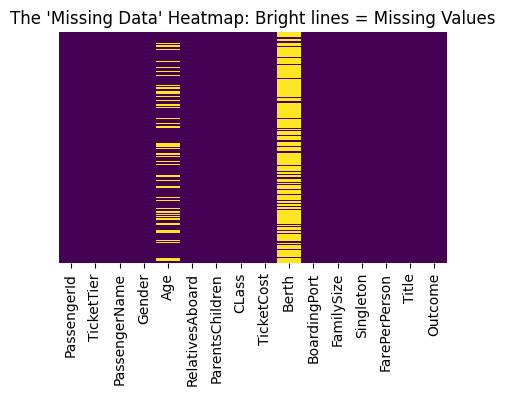

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("The 'Missing Data' Heatmap: Bright lines = Missing Values")
plt.show()

**2. Data Preparation** : cleaning, handling missing values 

In [8]:
train=train.drop(columns='Berth')      # droping Berth column because it has too many missing values

In [9]:
age_median=train['Age'].median()             # fill age with median 1st approach 
train['Age']=train['Age'].fillna(age_median)

In [10]:
Boarding_p=train['BoardingPort'].mode()[0]
train['BoardingPort']=train['BoardingPort'].fillna(Boarding_p)

train['BoardingPort'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [11]:
train.head(2)

,PassengerId,TicketTier,PassengerName,Gender,Age,RelativesAboard,ParentsChildren,CLass,TicketCost,BoardingPort,FamilySize,Singleton,FarePerPerson,Title,Outcome
0,338.376107,0.977533,"Partner, Mr. Austen",male,28.374231,0.005991,-0.024062,113043,29.104891,S,1,1,25.906873,Mr,0
1,732.225160,2.016456,"Berriman, Mr. William John",male,21.574386,0.091114,-0.021340,28425,11.033567,S,1,1,10.939094,Mr,0


In [12]:
print(train['TicketTier'].round().unique())

[1. 2. 3.]


**3. Feature Engineering** : creating meaningful features to train model

**4. Model Traning**

**5. Model Evaulation**

**6. Hyperparameter_Tuning**

**7. Deploy Model**